In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import mdtraj as md

from snrv import Snrv

In [ ]:
# load traj from GADES
traj = md.load("traj_0.5k_500freq_500clamp_1e+07steps.dcd", top="aib9.gro")

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)


In [3]:
def get_colvars(traj):
    phi_atoms = [
    [4, 6, 8, 17],
    [17, 19, 21, 30],
    [30, 32, 34, 43],
    [43, 45, 47, 56],
    [56, 58, 60, 69],
    [69, 71, 73, 82],
    [82, 84, 86, 95],
    [95, 97, 99, 108],
    [108, 110, 112, 121]
]

    psi_atoms = [
        [6, 8, 17, 19],
        [19, 21, 30, 32],
        [32, 34, 43, 45],
        [45, 47, 56, 58],
        [58, 60, 69, 71],
        [71, 73, 82, 84],
        [84, 86, 95, 97],
        [97, 99, 108, 110],
        [110, 112, 121, 123]
    ]

    def compute_custom_phi_psi(traj, phi_atoms, psi_atoms):
        phi_vals = np.array([md.compute_dihedrals(traj, [atoms])[:, 0] for atoms in phi_atoms]).T
        psi_vals = np.array([md.compute_dihedrals(traj, [atoms])[:, 0] for atoms in psi_atoms]).T
        return phi_vals, psi_vals
    phi, psi = compute_custom_phi_psi(traj, phi_atoms, psi_atoms)
    CVs = np.stack([phi, psi], axis=1)
    return CVs

In [4]:
angs = get_colvars(traj)
traj_x_sin = torch.Tensor(np.sin(angs).reshape(angs.shape[0], -1))
traj_x_cos = torch.Tensor(np.cos(angs).reshape(angs.shape[0], -1))
traj_x = torch.concat([traj_x_sin, traj_x_cos], dim=1)

In [8]:
input_size = traj_x.size()[1]
output_size = 3
hidden_depth = 3
hidden_size = 100
batch_norm = True
dropout_rate = 0.
lr = 5E-5
weight_decay = 0.
val_frac = 0.20
n_epochs = 100
batch_size = 20_000
VAMPdegree = 2
is_reversible = True
num_workers = 0

model = Snrv(input_size, output_size, hidden_depth=hidden_depth, hidden_size=hidden_size,
            batch_norm=batch_norm, dropout_rate=dropout_rate, lr=lr, weight_decay=weight_decay, 
            val_frac=val_frac, n_epochs=n_epochs, batch_size=batch_size, 
            VAMPdegree=VAMPdegree, is_reversible=is_reversible, num_workers=num_workers, device="cuda")
model = model.to("cuda")

In [ ]:
lag = 50
model.fit(traj_x, lag)
model.save_model(f'srv_models/snrv_{lag}.pt')

Epoch 0: 100%|██████████| 4/4 [00:01<00:00,  3.09batch/s]


[Epoch 0]	 training loss = -0.448	 validation loss = -0.940


Epoch 1: 100%|██████████| 4/4 [00:01<00:00,  3.94batch/s]


[Epoch 1]	 training loss = -0.533	 validation loss = -0.677


Epoch 2: 100%|██████████| 4/4 [00:01<00:00,  3.53batch/s]


...

[Epoch 97]	 training loss = -2.674	 validation loss = -2.669


Epoch 98: 100%|██████████| 4/4 [00:01<00:00,  3.87batch/s]


[Epoch 98]	 training loss = -2.677	 validation loss = -2.672


Epoch 99: 100%|██████████| 4/4 [00:01<00:00,  3.94batch/s]


[Epoch 99]	 training loss = -2.679	 validation loss = -2.675


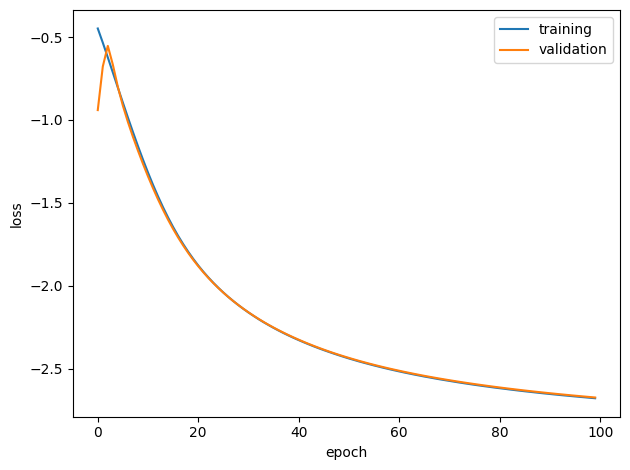

In [10]:
fig, ax = plt.subplots()
ax.plot(np.arange(len(model.training_losses)), model.training_losses)
ax.plot(np.arange(len(model.validation_losses)), model.validation_losses)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax.legend(['training','validation'])
fig.tight_layout()

In [12]:
evecs_SRV_unbiased = model.transform(traj_x.float()).cpu().detach().numpy()

In [13]:
def get_chi(CVs):
    sin_vals = np.sin(CVs) # in rad
    lambdas = np.sum(sin_vals, axis=1)* (-0.8)
    chi1 = lambdas[:, 2:7].sum(axis=1)
    chi2 =  lambdas[:, 2] + lambdas[:, 3] - lambdas[:, 5] - lambdas[:, 6]
    return chi1, chi2
chi1, chi2 = get_chi(angs)

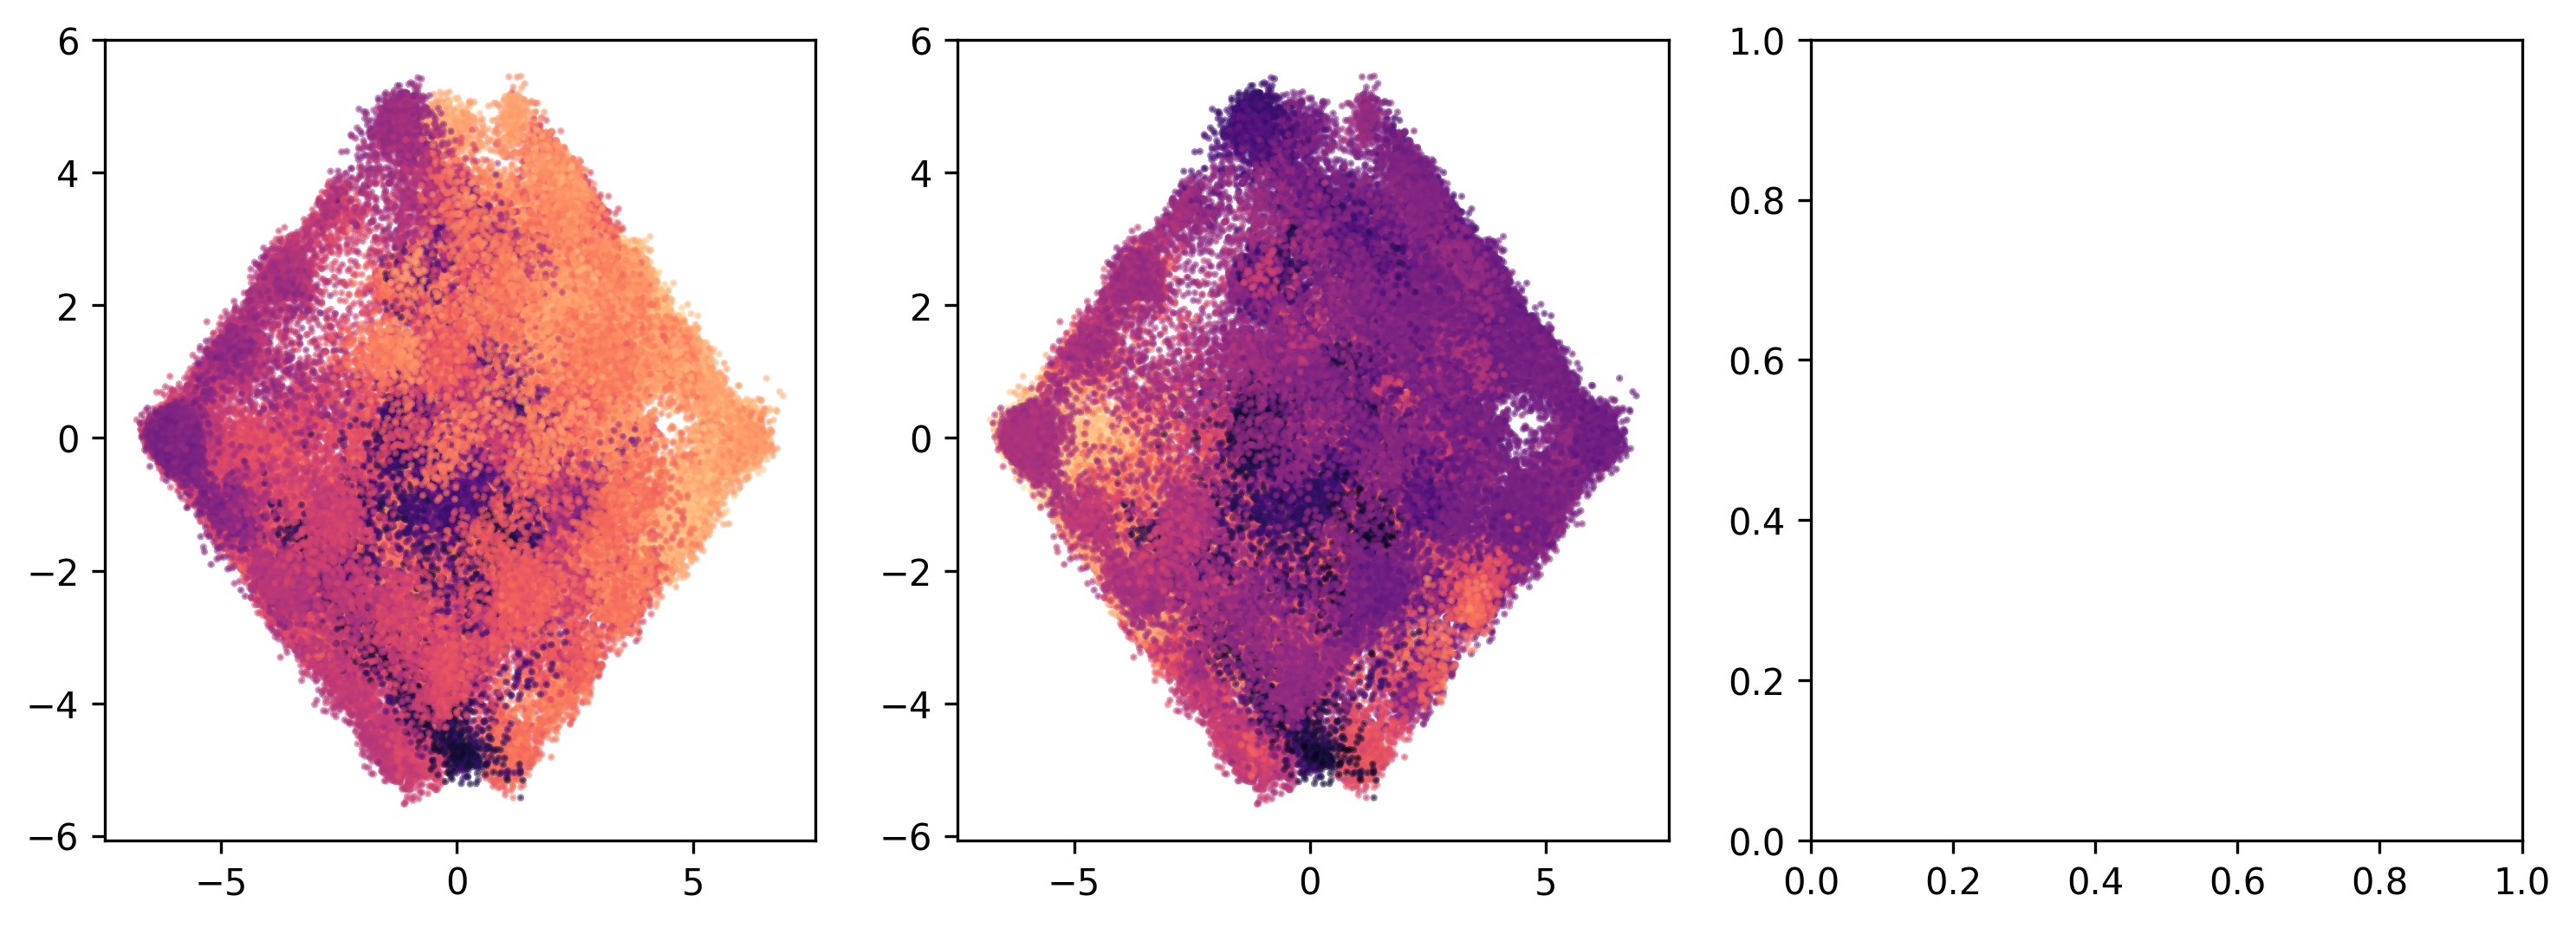

In [14]:
dataset = pd.DataFrame(evecs_SRV_unbiased, columns=[f"TIC{i}" for i in range(evecs_SRV_unbiased.shape[1])])

fig, axs = plt.subplots(1, 3, dpi=300, figsize=(12, 4))

axs = axs.flatten()
for i in range(1, evecs_SRV_unbiased.shape[1]):
    axs[i-1].scatter(chi1, chi2, c=dataset[f"TIC{i}"], alpha=0.5, s=1, cmap="magma")
plt.show()